In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.qt import qt
from multicam_tng.multicam2 import multicam_new_prediction_repeats

from astropy.table import Table
from multicam_tng.utils import get_an_from_mpeak_mah, generate_randoms


TNG_H = 0.6774
COLOR_CUT = 1.0  # Changed a little bit


from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf


In [ ]:
# this ist just metadata which sims share so it's ok to use TNG300
metadata = pd.read_csv("../../data/tng300-1-table.csv")
redshift_snaps = metadata["Redshift"].values
scales = 1 / (1 + redshift_snaps)
scales.shape

(100,)

In [ ]:
# load data
_hydro_raw = Table.read("../../data/hydro_final.ecsv")
flag = _hydro_raw["SubhaloFlag"]
hydro_raw = _hydro_raw[flag == 1]
len(hydro_raw)

101431

In [4]:
# Stellar mass cut
# NOTE: this cut can potentially bias the results so we avoid it
# although Ismael and Phil checked that it does not really matter.
# hydro_full = hydro_full[
#     hydro_full['StellarMass'] >= (1.4e8 * TNG_H)
# ]

# Add z12
hydro_raw["z12"] = (1 / hydro_raw["a12"]) - 1

In [5]:
# cut based on mpeak
log_mpeak = np.log10(hydro_raw["mpeak"])
mpeak_cut_high = log_mpeak > 11  # avoid resolution effects...
hydro_high = hydro_raw[mpeak_cut_high]
len(hydro_high)

12659

In [6]:
# sham application
x = np.log10(hydro_high["mpeak"].data)
y = np.log10(hydro_high["stellar_mass"].data)
logmstar_sham_high = qt(x, y)
logmstar_sham_high.shape

(12659,)

In [7]:
x1 = np.log10(hydro_raw["stellar_mass"])
x2 = np.log10(hydro_raw["mpeak"])
star_mask = (x1 > 9.5) & (x1 < 10.2) & (x2 > 11)
hydro_mstar_cut = hydro_raw[star_mask]

# get sham stellar mass bin predicted catalog
sham_mask = (logmstar_sham_high > 9.5) & (logmstar_sham_high < 10.2)
hydro_sham = hydro_high[sham_mask]


len(hydro_mstar_cut), len(hydro_sham)

(4051, 4051)

In [8]:
# CAM prediction for color
color_cam_pred = qt(hydro_sham["z12"].data, hydro_mstar_cut["color"])
color_cam_pred.shape

(4051,)

In [41]:
# multicam

# ns = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
ns = np.linspace(0, 1, 21)[1:-1]  # want to avoid 0, 1 edge cases


# can only train multicam on mpeak mass bin
_x = np.log10(hydro_raw["mpeak"])
mask = (_x > 11) & (_x < 12)
hydro_mpeak = hydro_raw[mask]

x_train = get_an_from_mpeak_mah(hydro_mpeak["mpeak_mah"], scales=scales, ns=ns)


In [42]:
# get star deviation w.r.t SHAM
log_mpeak = np.log10(hydro_raw["mpeak"])
log_mstar = np.log10(hydro_raw["stellar_mass"])
mask1 = log_mpeak > 11
mask2 = log_mpeak[mask1] < 12
star_dev = log_mstar[mask1][mask2] - logmstar_sham_high[mask2]
star_dev.shape

(11316,)

In [43]:
y_train = np.stack([hydro_mpeak["color"], star_dev], axis=-1)
y_train.shape

(11316, 2)

In [44]:
# get multicam prediction for deviation in the mpeak mass bin
y_pred = multicam_new_prediction_repeats(x_train, x_train, y_train, y_train)
star_dev_pred = y_pred[:, 1]
star_dev_pred.shape

(11316,)

In [45]:
# now get predicted stellar mass bin
pred_stellar_mass = star_dev_pred + logmstar_sham_high[mask2]
_mask = (pred_stellar_mass > 9.5) & (pred_stellar_mass < 10.2)
hydro_multicam = hydro_mpeak[_mask]
len(hydro_multicam)

4176

In [46]:
x_test = get_an_from_mpeak_mah(hydro_multicam["mpeak_mah"], scales=scales, ns=ns)

# keep training the same
y_train = np.stack([hydro_mpeak["color"], star_dev], axis=-1)

# second feature will not be used!!!
# this is just a trick while I get class implementation.
y_true = np.stack(
    [hydro_mstar_cut["color"], np.ones_like(hydro_mstar_cut["color"])], axis=-1
)


color_multicam_pred = multicam_new_prediction_repeats(x_test, x_train, y_train, y_true)[
    :, 0
]
color_multicam_pred.shape

(4176,)

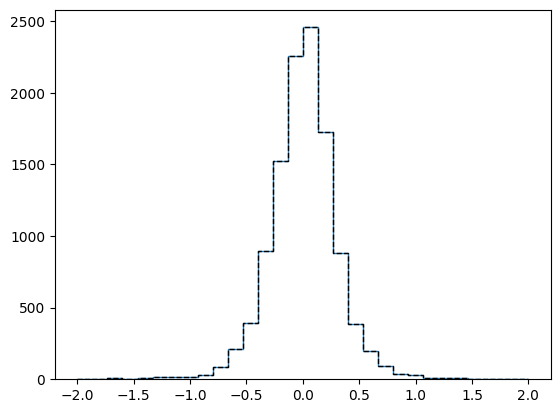

In [47]:
# same star deviation distribution
bins = np.linspace(-2, 2, 31)
plt.hist(y_train[:, 1], bins=bins, histtype="step", range=(-2, 2))
plt.hist(star_dev_pred, bins=bins, histtype="step", range=(-2, 2), ls="--", color="k");

(array([0.        , 0.        , 0.        , 0.00736811, 0.01473622,
        0.02947244, 0.03684055, 0.13999411, 0.2063071 , 0.37577365,
        0.61892131, 1.00206307, 1.48099027, 1.9746537 , 2.28411435,
        2.56410256, 2.40200413, 2.17359269, 1.90097259, 1.53256705,
        1.3631005 , 1.16416151, 0.92838196, 0.81049219, 0.52313587,
        0.53050398, 0.63365753, 0.97995874, 1.53256705, 1.9083407 ,
        1.0904804 , 0.41261421, 0.13262599, 0.01473622, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 array([0.2   , 0.2325, 0.265 , 0.2975, 0.33  , 0.3625, 0.395 , 0.4275,
        0.46  , 0.4925, 0.525 , 0.5575, 0.59  , 0.6225, 0.655 , 0.6875,
        0.72  , 0.7525, 0.785 , 0.8175, 0.85  , 0.8825, 0.915 , 0.9475,
        0.98  , 1.0125, 1.045 , 1.0775, 1.11  , 1.1425, 1.175 , 1.2075,
        1.24  , 1.2725, 1.305 , 1.3375, 1.37  , 1.4025, 1.435 , 1.4675,
        1.5   ]),
 [<matplotlib.patches.Polygon at 0x11a115590>])

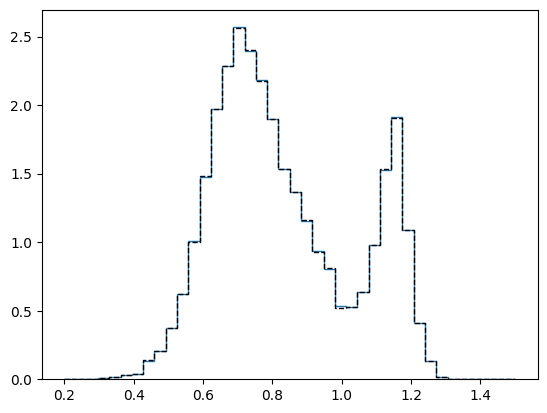

In [48]:
# same color distribution as true stellar mass bin
# NOTE: not same number of galaxies in bin so need to use 'density=True'
bins = np.linspace(0.2, 1.5, 41)


plt.hist(hydro_mstar_cut["color"], bins=bins, histtype="step", ls="-", density=True)
plt.hist(
    color_multicam_pred, bins=bins, histtype="step", ls="--", density=True, color="k"
)

## Clustering Results

In [20]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(lbox=Lbox, n_randoms=50_000, rng=41)

randoms.shape

(50000, 3)

In [21]:
true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]

multicam_red = hydro_multicam[color_multicam_pred > COLOR_CUT]
multicam_blue = hydro_multicam[color_multicam_pred <= COLOR_CUT]


cam_red = hydro_sham[color_cam_pred > COLOR_CUT]
cam_blue = hydro_sham[color_cam_pred <= COLOR_CUT]

In [25]:
print(
    len(red_true),
    len(cam_red),
    len(multicam_red),
    len(blue_true),
    len(cam_blue),
    len(multicam_blue),
)

# but propotion is the same!!
print(
    len(red_true) / (len(red_true) + len(blue_true)),
    len(multicam_red) / (len(multicam_red) + len(multicam_blue)),
)


981 981 1012 3070 3070 3164
0.24216242902986918 0.24233716475095785


In [26]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [27]:
xyz_red = return_xyz_formatted_array(
    cam_red["x"].data, cam_red["y"].data, cam_red["z"].data
)
xyz_blue = return_xyz_formatted_array(
    cam_blue["x"].data, cam_blue["y"].data, cam_blue["z"].data
)


xi_red_cam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_cam = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [28]:
xyz_red = return_xyz_formatted_array(
    multicam_red["x"].data,
    multicam_red["y"].data,
    multicam_red["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue["x"].data,
    multicam_blue["y"].data,
    multicam_blue["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


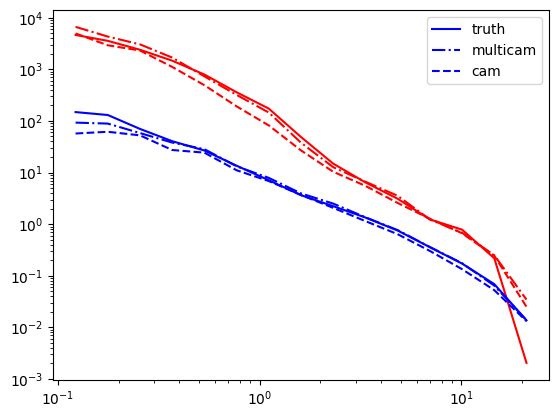

In [29]:
plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b", label="truth")

plt.loglog(rbin_centers, xi_red_multicam, c="r", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="b", ls="-.", label="multicam")

plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--", label="cam")

plt.legend()

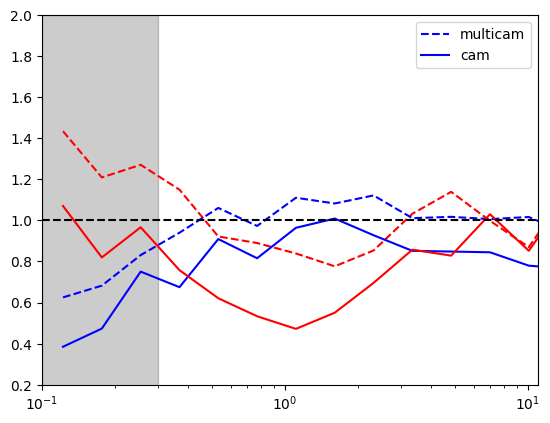

In [30]:
plt.semilogx(rbin_centers, xi_red_multicam / xi_red_true, c="r", ls="--")
plt.semilogx(
    rbin_centers, xi_blue_multicam / xi_blue_true, c="b", ls="--", label="multicam"
)
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-", label="cam")
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.legend()

# plt.axvline(0.3, c="k")
plt.fill_betweenx([-2, 2], 0.1, 0.3, color="k", alpha=0.2)
# i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output

# SHAM comparison 

In [49]:
xyz_true = return_xyz_formatted_array(
    hydro_mstar_cut["x"].data, hydro_mstar_cut["y"].data, hydro_mstar_cut["z"].data
)
xyz_multicam = return_xyz_formatted_array(
    hydro_multicam["x"].data, hydro_multicam["y"].data, hydro_multicam["z"].data
)

xyz_cam = return_xyz_formatted_array(
    hydro_sham["x"].data, hydro_sham["y"].data, hydro_sham["z"].data
)

xi_true = tpcf(xyz_true, rbins, randoms=randoms, period=Lbox, num_threads="max")
xi_multicam = tpcf(xyz_multicam, rbins, randoms=randoms, period=Lbox, num_threads="max")
xi_cam = tpcf(xyz_cam, rbins, randoms=randoms, period=Lbox, num_threads="max")

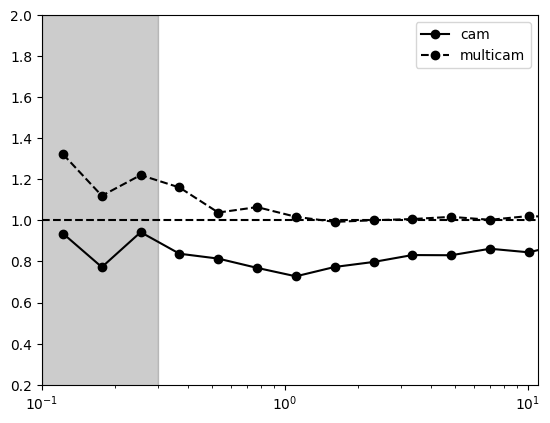

In [50]:
plt.semilogx(rbin_centers, xi_cam / xi_true, c="k", ls="-", marker="o", label="cam")
plt.semilogx(
    rbin_centers, xi_multicam / xi_true, c="k", ls="--", marker="o", label="multicam"
)


plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.fill_betweenx([-2, 2], 0.1, 0.3, color="k", alpha=0.2)

plt.legend()